In [1]:
import pandas as pd
import numpy as np

# DataSet Overview

In [2]:
df = pd.read_csv('online_retail.csv' , encoding="latin1")

In [3]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


In [4]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')

In [5]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
Price               0
Customer ID    135080
Country             0
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      541910 non-null  object 
 1   StockCode    541910 non-null  object 
 2   Description  540456 non-null  object 
 3   Quantity     541910 non-null  int64  
 4   InvoiceDate  541910 non-null  object 
 5   Price        541910 non-null  float64
 6   Customer ID  406830 non-null  float64
 7   Country      541910 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [21]:
(df['Quantity']<0).sum()

8905

In [25]:
(df['Price'] <= 0).sum()

40

In [22]:
df = df.dropna(subset=['Customer ID'])

In [26]:
df = df.dropna(subset=['Description'])

In [27]:
df = df[df['Quantity'] > 0]

In [28]:
df = df[df['Price'] > 0]

In [30]:
# Create transaction value

df['TotalPrice'] = df['Quantity'] * df['Price']

In [33]:
# Convert date column
df['InvoiceDate'] = pd.to_datetime(
    df['InvoiceDate'],
    dayfirst=True
)

In [34]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


# RFM Analysis

In [35]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'Invoice': 'nunique',
    'TotalPrice': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

In [36]:
rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [37]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2054.270609
std,100.014169,7.697998,8989.229895
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,307.415000
50%,51.000000,2.000000,674.485000
75%,142.000000,5.000000,1661.740000
max,374.000000,209.000000,280206.020000


# :- Looking for skewness

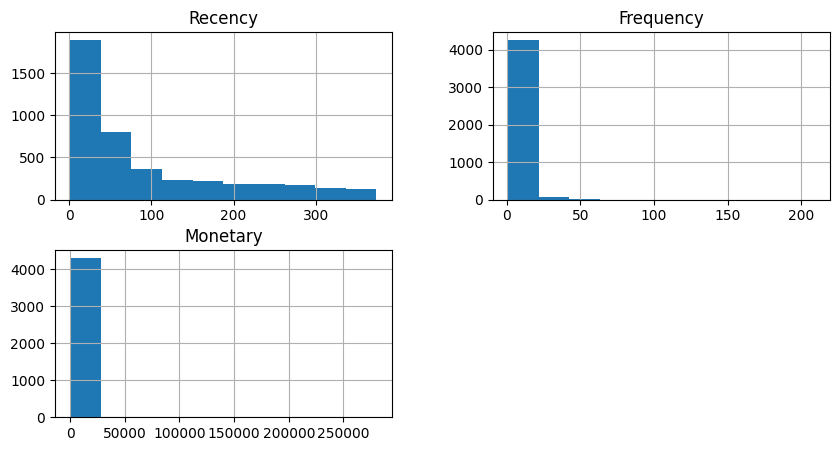

In [38]:
import matplotlib.pyplot as plt

rfm.hist(figsize=(10,5))
plt.show()

In [39]:
rfm['Recency'] = np.log1p(rfm['Recency'])  # using log for skewness
rfm['Frequency'] = np.log1p(rfm['Frequency'])
rfm['Monetary'] = np.log1p(rfm['Monetary'])

# :- Scaling the Data

In [40]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

# :- Finding the Best Number of Clusters

In [41]:
from sklearn.cluster import KMeans

wcss = []

for k in range(1,11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(rfm_scaled)
    wcss.append(km.inertia_)

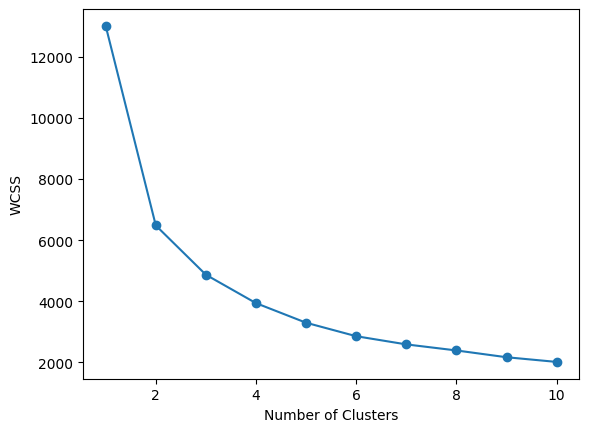

In [42]:
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

# :- Silhouette Score

In [44]:
from sklearn.metrics import silhouette_score

for k in range(2,11):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(rfm_scaled)

    score = silhouette_score(rfm_scaled, labels)
    print(f"K={k}: {score:.4f}")

K=2: 0.4332
K=3: 0.3360
K=4: 0.3371
K=5: 0.3173
K=6: 0.3143
K=7: 0.2875
K=8: 0.2866
K=9: 0.2947
K=10: 0.2764


# :- Train Final Model

In [45]:
kmeans = KMeans(n_clusters=4, random_state=42)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# :- Analyze the Clusters

In [50]:
cluster_summary = rfm.groupby('Cluster').mean()

print(cluster_summary)     # cluster :- 0 means VIP Customers
                                     #  1 means Loyal Customers
                                     #  2 means At-Risk Customers
                                     #  3 menas New Customers

          Recency  Frequency  Monetary
Cluster                               
0        2.701327   1.090700  6.091577
1        2.160515   2.478709  8.356989
2        4.015904   1.565575  7.251444
3        5.024273   0.814544  5.592418


# :- Visulize with PCA

In [47]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

rfm_pca = pca.fit_transform(rfm_scaled)

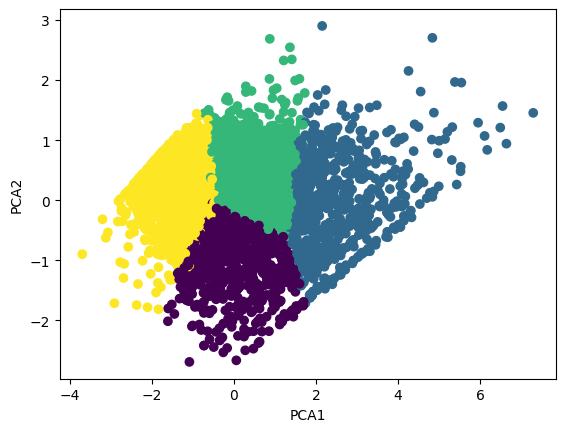

In [48]:
plt.scatter(
    rfm_pca[:,0],
    rfm_pca[:,1],
    c=rfm['Cluster']
)
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.show()